<a href="https://colab.research.google.com/github/jaredlan1/getting_started_with_ML/blob/main/KAN_Hello_World.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
pip install pykan

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 78.1/78.1 kB 1.6 MB/s eta 0:00:00


In [2]:
import kan
import torch
import matplotlib.pyplot as plt

In [3]:
f = lambda x: torch.exp(torch.sin(torch.pi*x[:,[0]])+x[:,[1]]**2)
dataset = kan.utils.create_dataset(f, n_var=2)

checkpoint directory created: ./model
saving model version 0.0


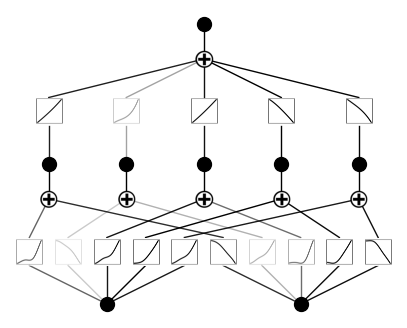

In [10]:
#2 inputs, 5 hidden, 1 output, 3 grid intervals, cubic splines
model = kan.KAN(width=[2,5,1], grid=3, k=3, seed=42)

model(dataset['train_input'])
model.plot()
plt.show()

| train_loss: 1.54e-02 | test_loss: 1.57e-02 | reg: 5.95e+00 | : 100%|█| 50/50 [00:08<00:00,  6.21it


saving model version 0.1


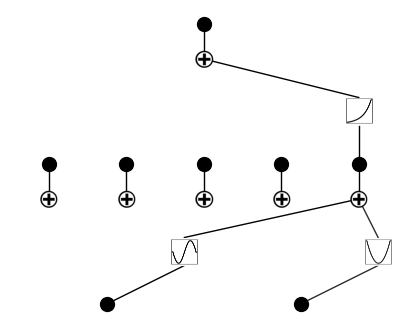

saving model version 0.2


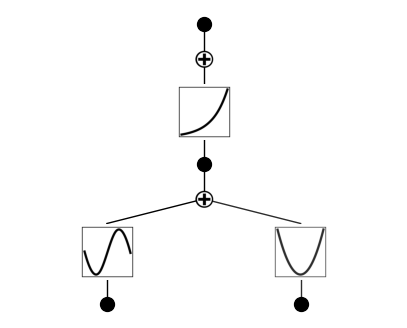

In [11]:
model.fit(dataset, opt='LBFGS', steps=50, lamb=0.001)
model.plot()
plt.show()

model = model.prune()
model.plot()
plt.show()

In [13]:
model = model.refine(10)
model.fit(dataset, opt='LBFGS', steps=50);
model.plot()
plt.show()

saving model version 0.5


| train_loss: 4.65e-04 | test_loss: 4.90e-04 | reg: 7.63e+00 | : 100%|█| 50/50 [00:02<00:00, 20.80it

saving model version 0.6


In [17]:
model.auto_symbolic()

model.fit(dataset, opt='LBFGS', steps=50);
from kan.utils import ex_round
ex_round(model.symbolic_formula()[0][0],4)

skipping (0,0,0) since already symbolic
skipping (0,1,0) since already symbolic
skipping (1,0,0) since already symbolic
saving model version 0.11


| train_loss: 3.44e-06 | test_loss: 3.49e-06 | reg: 0.00e+00 | : 100%|█| 50/50 [00:04<00:00, 12.30it


saving model version 0.12


1.0*exp(0.99945068359375*x_2**2 + 1.0*sin(3.1416*x_1))